<a href="https://colab.research.google.com/github/mayura-andrew/ml-experiments/blob/main/MNIST_Neural_Network_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/mnielsen/neural-networks-and-deep-learning.git

Cloning into 'neural-networks-and-deep-learning'...
remote: Enumerating objects: 1172, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 1172 (delta 4), reused 0 (delta 0), pack-reused 1166 (from 3)
Receiving objects: 100% (1172/1172), 20.43 MiB | 19.07 MiB/s, done.
Resolving deltas: 100% (581/581), done.


In [19]:
ls

neural-networks-and-deep-learning/  sample_data/


A module to implement the stochastic gradient descent learning algorithm for a feedforward neural network. Gradients are calculated using backpropagation.

In [3]:
import numpy as np

# Network Class

class Network(object):

  def __init__(self, sizes):
    self.num_layers = len(sizes)
    self.sizes = sizes
    self.biases = [np.random.randn(y, 1) for y in sizes[1:]]
    self.weights = [np.random.randn(y, x) for x, y in zip(sizes[:-1], sizes[1:])]

  def sigmoid(z):
    return 1.0/(1.0+np.exp(-z))

# note input z is a vector or Numpy array



---

### 1. The Setup

```python
import numpy as np
class Network(object):
```
* **`import numpy as np`**: NumPy is a library for fast, efficient matrix and vector operations. In neural networks, calculating the output of a layer requires multiplying large grids of numbers (weights) by lists of numbers (inputs). NumPy handles this heavy lifting.
* **`class Network(object):`**: We are creating a "blueprint" (a class) for a neural network. Every time we want a new network, we will build an *instance* of this class.

### 2. Defining the Architecture

```python
def __init__(self, sizes):
    self.num_layers = len(sizes)
    self.sizes = sizes
```
* **`sizes`**: This list is the DNA of your network. If you pass in `[2, 3, 1]`, you are telling the network: "Create an input layer with 2 neurons, a hidden layer with 3 neurons, and an output layer with 1 neuron."
* **`self.num_layers`**: Simply counts the layers. For `[2, 3, 1]`, this is 3.



### 3. Initializing the Biases

```python
    self.biases = [np.random.randn(y, 1) for y in sizes[1:]]
```
To understand this, we need the first principle of a single artificial neuron. A neuron takes inputs, multiplies them by weights, and adds a **bias**. The bias determines how easy it is to get that neuron to "fire" (output a high value).

* **`sizes[1:]`**: Notice the `1:`. This slices the `sizes` list to skip the very first layer (the input layer). Why? Because **input neurons do not have biases**. They just passively receive the raw data we feed them.
* **`np.random.randn(y, 1)`**: For every layer after the input, this generates a column vector (a matrix with 1 column and $y$ rows) of random numbers. The numbers are drawn from a standard normal distribution (mean of 0, standard deviation of 1). Random initialization is crucial; if all weights and biases started at zero, the network would never learn because every neuron would compute the exact same gradients.

### 4. Initializing the Weights

```python
    self.weights = [np.random.randn(y, x) for x, y in zip(sizes[:-1], sizes[1:])]
```
This is the most mathematically dense line in the snippet. Weights are the "connections" between neurons in one layer and neurons in the next.

* **`zip(sizes[:-1], sizes[1:])`**: This cleverly pairs up the layers to define the connections.
    * `sizes[:-1]` is every layer *except the last* (the senders).
    * `sizes[1:]` is every layer *except the first* (the receivers).
    * If `sizes` is `[2, 3, 1]`, `zip` pairs them as `(2, 3)` and then `(3, 1)`. This means "2 neurons connect to 3 neurons", then "3 neurons connect to 1 neuron". Let's call these pairs $(x, y)$.
* **`np.random.randn(y, x)`**: For each pair of layers, we create a matrix of weights.
    * $x$ is the number of neurons in the *previous* layer.
    * $y$ is the number of neurons in the *current* layer.
    * **Why is the matrix dimension $y \times x$ and not $x \times y$?** This is purely to make the linear algebra elegant later on. The core equation for calculating the output of a layer is $Z = W \cdot A + B$.
    * If $W$ (weights) is a $y \times x$ matrix, and $A$ (activations from the previous layer) is an $x \times 1$ column vector, matrix multiplication rules state that a $(y \times x)$ multiplied by an $(x \times 1)$ yields a $(y \times 1)$ matrix. This perfectly matches the dimensions of our biases ($B$), allowing us to add them together smoothly!

### Summary
When you run `net = Network([2, 3, 1])`, you aren't just making a list. You are setting up the precise, randomly-initialized matrices required to pass data forward through a mathematical pipeline, completely ready for the next steps: feedforward calculation and backpropagation.

### Alternative Initialization (Without `zip`)

You can achieve the same result by iterating through the indices of the layers. Since weights connect layer $i-1$ to layer $i$, we can loop from index 1 to the end of the `sizes` list.

In [11]:
# Example of initializing weights without zip
sizes = [2, 3, 1]
weights = []

for i in range(1, len(sizes)):
    # sizes[i] is the number of neurons in the current layer (y)
    # sizes[i-1] is the number of neurons in the previous layer (x)
    node_weights = np.random.randn(sizes[i], sizes[i-1])
    weights.append(node_weights)

# Verification
for idx, w in enumerate(weights):
    print(f"Layer {idx} to {idx+1} weight matrix shape: {w.shape}")

Layer 0 to 1 weight matrix shape: (3, 2)
Layer 1 to 2 weight matrix shape: (1, 3)


In [12]:
sizes = [2, 3, 1]
print(f"Initial sizes list: {sizes}\n")

for i in range(1, len(sizes)):
    print(f"--- Iteration for i = {i} ---")
    prev_layer_size = sizes[i-1]
    curr_layer_size = sizes[i]

    print(f"Connecting Layer {i-1} ({prev_layer_size} neurons) to Layer {i} ({curr_layer_size} neurons)")
    print(f"Generating matrix with shape (curr, prev) -> ({curr_layer_size}, {prev_layer_size})")

    # Simulate the weight generation
    temp_weights = np.random.randn(curr_layer_size, prev_layer_size)
    print(f"Resulting weight matrix shape: {temp_weights.shape}\n")

Initial sizes list: [2, 3, 1]

--- Iteration for i = 1 ---
Connecting Layer 0 (2 neurons) to Layer 1 (3 neurons)
Generating matrix with shape (curr, prev) -> (3, 2)
Resulting weight matrix shape: (3, 2)

--- Iteration for i = 2 ---
Connecting Layer 1 (3 neurons) to Layer 2 (1 neurons)
Generating matrix with shape (curr, prev) -> (1, 3)
Resulting weight matrix shape: (1, 3)



In [4]:
net = Network([2, 3, 1])

In [5]:
print(net.num_layers)

3


In [6]:
print(net.sizes)

[2, 3, 1]


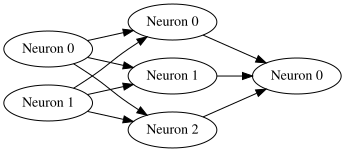

In [7]:
import graphviz

def visualize_network(sizes):
    dot = graphviz.Digraph(comment='Neural Network', graph_attr={'rankdir': 'LR'})

    # Create nodes for each layer
    for l, size in enumerate(sizes):
        with dot.subgraph(name=f'cluster_{l}') as c:
            c.attr(label=f'Layer {l} ({"Input" if l==0 else "Output" if l==len(sizes)-1 else "Hidden"})')
            for i in range(size):
                dot.node(f'l{l}n{i}', f'Neuron {i}')

    # Create edges (weights) between layers
    for l in range(len(sizes) - 1):
        for i in range(sizes[l]):
            for j in range(sizes[l+1]):
                dot.edge(f'l{l}n{i}', f'l{l+1}n{j}')

    return dot

# Visualize the network instance 'net'
network_graph = visualize_network(net.sizes)
network_graph

In [8]:
net = Network([2, 3, 5, 1])

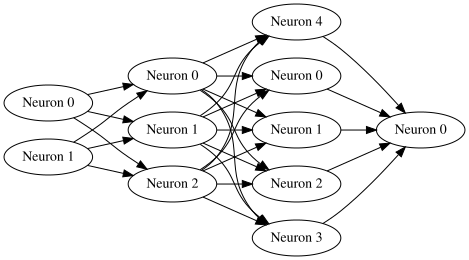

In [10]:
network_graph = visualize_network(net.sizes)
network_graph

### Proving the Vectorized Feedforward Equation

In neural networks, we transition from calculating the activation of a single neuron (Component Form) to calculating an entire layer at once using matrix operations (Vectorized Form).

**1. The Component Form**
For a single neuron $j$, the activation $a_j$ is:
$$a_j = \sigma\left(\sum_k w_{jk} a_k + b_j\right)$$

**2. The Vectorized Form**
For the entire layer, the activations $a'$ are computed as:
$$a' = \sigma(Wa + b)$$

**3. The Proof: Expanding the Matrix Equation**
Let's define our matrices for a network where the previous layer has $K$ neurons and the current layer has $J$ neurons:

* **$W$ (Weights):** A $J \times K$ matrix.
* **$a$ (Previous Activations):** A $K \times 1$ column vector.
* **$b$ (Biases):** A $J \times 1$ column vector.

First, we calculate the dot product $Wa$:
$$Wa = \begin{bmatrix} \sum_{k=1}^K w_{1k}a_k \\ \sum_{k=1}^K w_{2k}a_k \\ \vdots \\ \sum_{k=1}^K w_{Jk}a_k \end{bmatrix}$$

Next, we add the bias vector $b$:
$$Wa + b = \begin{bmatrix} \sum_{k=1}^K w_{1k}a_k + b_1 \\ \sum_{k=1}^K w_{2k}a_k + b_2 \\ \vdots \\ \sum_{k=1}^K w_{Jk}a_k + b_J \end{bmatrix}$$

Finally, we apply the sigmoid function $\sigma$ element-wise to the resulting vector:
$$a' = \begin{bmatrix} \sigma\left(\sum_{k=1}^K w_{1k}a_k + b_1\right) \\ \sigma\left(\sum_{k=1}^K w_{2k}a_k + b_2\right) \\ \vdots \\ \sigma\left(\sum_{k=1}^K w_{Jk}a_k + b_J\right) \end{bmatrix}$$

**Conclusion:**
If we look at the $j$-th row of our expanded vector, it is exactly $a'_j = \sigma\left(\sum_{k=1}^K w_{jk} a_k + b_j\right)$. This proves that the matrix multiplication $Wa+b$ mathematically achieves the exact same result as iterating through every individual neuron, but allows us to use highly optimized linear algebra libraries like NumPy to do it instantaneously.



In [13]:
def sigmoid(z):
  return 1.0/(1.0+np.exp(-z))

# note input z is a vector or Numpy array

In [ ]:
def sigmoid_prime(z):
  """Derivative of the sigmoid function."""
  return sigmoid(z)*(1-sigmoid(z))

In [14]:
def feedforward(self, a):
  """Return the output of the network if "a" is input."""
  for b, w in zip(self.biases, self.weights):
    a = sigmoid(np.dot(w, a) +b)
  return a

In [16]:
def SGD(self, training_data, epochs, mini_batch_size, eta, test_data=None):
  """Train the neural network using mini-batch stochastic gradient descent. The ``training data`` is a list
  of tuples ``(x, y)`` representing the training inputs and the desired outputs.
  other non-optional parameters are self-explanatory. If ``test_data`` is provided then network will be
  evaluated against the test data after each epoch, and partial progress printed out. This is useful for
  tracking progress, but slows things down substantially."""

  if test_data: n_test = len(test_data)
  n = len(training_data)
  for j in xrange(epochs):
    random.shuffle(training_data)
    mini_batches = [training_data[k:k+mini_batch_size]
        for k in xrange(0, n, mini_batch_size)]
    for mini_batch in mini_batches:
          self.update_mini_batch(mini_batch, eta)

    if test_data:
      print ("Epoch {0}: {1} / {2}".format(
        j, self.evaluate(test_data), n_test))
    else:
      print ("Epoch {0} complete".format(j))


In [ ]:
def update_mini_batch(self, mini_batch, eta):
  """Update the network's weights and biases by applying gradient descent using
  backpropagation to a single mini batch.
  The ``mini_batch`` is a list of tuples ``(x, y)``, and ``eta`` is the learning
  rate."""

  nable_b = [np.zeros(b.shape) for b in self.biases]
  nable_w = [np.zeros(w.shape) for w in self.weights]
  for x, y in mini_batch:
    delta_nable_b, delta_nable_w = self.backpro(x, y)
    nable_b = [nb+dnb for nb, dnb in zip(nable_b, delta_nable_b)]
    nable_w = [nw+dnw for nw, dnw in zip(nable_w, delta_nable_w)]

  self.weights = [w-(eta/len(mini_batch))*nw for w, nw in zip(self.weights, nable_w)]
  self.biases = [b-(eta/len(mini_batch))*nb for b, nb in zip(self.biases, nable_b)]


In [ ]:
def backpro(self, x, y):

  """Return a tuple ``(nable_b, nable_w)`` representing the gradient for
  the cost function C_x. ``nable_b`` and ``nable_w`` are layer-by-layer
  lists of numpy arrays, similar to ``self.biases`` and ``self.weights``."""

  nable_b = [np.zeros(b.shape) for b in self.biases]
  nable_w = [np.zeros(w.shape) for w in self.weights]


  # feedforward
  activation = x
  activations = [x] # list to store all the activations, layer by layer
  zs = [] # list to store all the z vectors, layer by layer

  for b, w in zip(self.biases, self.weights):
    z = np.dot(w, activation) + b
    zs.append(z)
    activation = sigmoid(z)
    activations.append(activation)

  # backword pass
  delta = self.cost_derivative(activations[-1], y) * \
            sigmoid_prime(zs[-1])
  nable_b[-1] = delta
  nable_w[-1] = np.dot(delta, activations[-2].transpose())

  for 1 in xrange(2, self.num_layers):
    z = zs[-l]
    sp = sigmoid_prime(z)
    delta = np.dot(self.weights[-1+1].transpose(), delta) * sp
    nable_b[-l] = delta
    nable_w[-l] = np.dot(delta, activations[-1,-1].transpose())
  return (nable_b, nable_w)


### Explanation of Core Functions

#### 1. Sigmoid Function (`sigmoid`)
```python
def sigmoid(z):
  return 1.0/(1.0+np.exp(-z))
```
* **Purpose**: This is our **activation function**. It squashes any input value `z` into a range between 0 and 1.
* **Why?**: It introduces non-linearity, allowing the network to learn complex patterns, and its output can be interpreted as the probability of a neuron 'firing'.

#### 2. Feedforward (`feedforward`)
```python
for b, w in zip(self.biases, self.weights):
    a = sigmoid(np.dot(w, a) + b)
```
* **Purpose**: Computes the output of the network for a given input `a`.
* **Logic**: It loops through each layer, calculating $a' = \sigma(Wa + b)$. The output of one layer becomes the input for the next until we reach the final layer.

#### 3. Stochastic Gradient Descent (`SGD`)
* **Purpose**: The high-level training loop.
* **Process**:
    1. **Shuffle**: Randomizes training data every epoch to prevent the network from memorizing the order of samples.
    2. **Mini-batches**: Splits data into small groups. Updating weights after a small batch is much faster than waiting for the entire dataset.
    3. **Epochs**: One epoch is one full pass through the entire training dataset.

#### 4. Update Mini-Batch (`update_mini_batch`)
* **Purpose**: Adjusts the weights and biases for a single small group of data.
* **Backpropagation**: For every example in the batch, it calls `backpro` (backpropagation) to calculate the 'gradient' (the direction to change weights to reduce error).
* **The Update Rule**:
  $$w \rightarrow w - \frac{\eta}{m} \sum \nabla w$$
  Where $\eta$ (eta) is the **learning rate** and $m$ is the batch size. We subtract a fraction of the gradient to 'step' down the error hill.

In [ ]:
def evaluate(self, test_data):
  """Return the number of test inputs for which the neural network outputs the
  correct result. Note that the neural network's output is assumed to be the
  index of whichever neuron in the final layer has the highest activation."""
  test_results = [(np.argmax(self.feedforward(x)), y) for (x, y) in test_data]
  return sum(int(x == y) for (x, y) in test_results)

In [ ]:
def cost_derivative(self, output_activations, y):
  """Return the vector of partial derivatives \partial C_x / \partial a for the output activations."""
  return (output_activations - y)

In [34]:
#### Libraries
import random
import numpy as np

class Network(object):
    def __init__(self, sizes):
        self.num_layers = len(sizes)
        self.sizes = sizes
        self.biases = [np.random.randn(y, 1) for y in sizes[1:]]
        self.weights = [np.random.randn(y, x) for x, y in zip(sizes[:-1], sizes[1:])]

    def feedforward(self, a):
        for b, w in zip(self.biases, self.weights):
            a = sigmoid(np.dot(w, a)+b)
        return a

    def SGD(self, training_data, epochs, mini_batch_size, eta, test_data=None):
        if test_data: n_test = len(test_data)
        n = len(training_data)
        for j in range(epochs): # Python 3 range
            random.shuffle(training_data)
            mini_batches = [training_data[k:k+mini_batch_size] for k in range(0, n, mini_batch_size)]
            for mini_batch in mini_batches:
                self.update_mini_batch(mini_batch, eta)
            if test_data:
                print ("Epoch {0}: {1} / {2}".format(j, self.evaluate(test_data), n_test))
            else:
                print ("Epoch {0} complete".format(j))

    def update_mini_batch(self, mini_batch, eta):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x, y)
            nabla_b = [nb+dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
            nabla_w = [nw+dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]
        self.weights = [w-(eta/len(mini_batch))*nw for w, nw in zip(self.weights, nabla_w)]
        self.biases = [b-(eta/len(mini_batch))*nb for b, nb in zip(self.biases, nabla_b)]

    def backprop(self, x, y):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        activation = x
        activations = [x]
        zs = []
        for b, w in zip(self.biases, self.weights):
            z = np.dot(w, activation)+b
            zs.append(z)
            activation = sigmoid(z)
            activations.append(activation)
        delta = self.cost_derivative(activations[-1], y) * sigmoid_prime(zs[-1])
        nabla_b[-1] = delta
        nabla_w[-1] = np.dot(delta, activations[-2].transpose())
        for l in range(2, self.num_layers):
            z = zs[-l]
            sp = sigmoid_prime(z)
            delta = np.dot(self.weights[-l+1].transpose(), delta) * sp
            nabla_b[-l] = delta
            nabla_w[-l] = np.dot(delta, activations[-l-1].transpose())
        return (nabla_b, nabla_w)

    def evaluate(self, test_data):
        test_results = [(np.argmax(self.feedforward(x)), y) for (x, y) in test_data]
        return sum(int(x == y) for (x, y) in test_results)

    def cost_derivative(self, output_activations, y):
        return (output_activations-y)

def sigmoid(z):
    return 1.0/(1.0+np.exp(-z))

def sigmoid_prime(z):
    return sigmoid(z)*(1-sigmoid(z))

### Explanation of Core Functions

#### 1. Sigmoid Function (`sigmoid`)
```python
def sigmoid(z):
  return 1.0/(1.0+np.exp(-z))
```
* **Purpose**: This is our **activation function**. It squashes any input value `z` into a range between 0 and 1.
* **Why?**: It introduces non-linearity, allowing the network to learn complex patterns, and its output can be interpreted as the probability of a neuron 'firing'.

#### 2. Feedforward (`feedforward`)
```python
for b, w in zip(self.biases, self.weights):
    a = sigmoid(np.dot(w, a) + b)
```
* **Purpose**: Computes the output of the network for a given input `a`.
* **Logic**: It loops through each layer, calculating $a' = \sigma(Wa + b)$. The output of one layer becomes the input for the next until we reach the final layer.

#### 3. Stochastic Gradient Descent (`SGD`)
* **Purpose**: The high-level training loop.
* **Process**:
    1. **Shuffle**: Randomizes training data every epoch to prevent the network from memorizing the order of samples.
    2. **Mini-batches**: Splits data into small groups. Updating weights after a small batch is much faster than waiting for the entire dataset.
    3. **Epochs**: One epoch is one full pass through the entire training dataset.

#### 4. Update Mini-Batch (`update_mini_batch`)
* **Purpose**: Adjusts the weights and biases for a single small group of data.
* **Backpropagation**: For every example in the batch, it calls `backpro` (backpropagation) to calculate the 'gradient' (the direction to change weights to reduce error).
* **The Update Rule**:
  $$w \rightarrow w - \frac{\eta}{m} \sum \nabla w$$
  Where $\eta$ (eta) is the **learning rate** and $m$ is the batch size. We subtract a fraction of the gradient to 'step' down the error hill.

### Mathematical Implementation Details

Our implementation is based on the four fundamental equations of backpropagation. Here is the mathematical detail behind the code:

#### 1. The Cost Function
We use the Quadratic Cost (Mean Squared Error) for this implementation:
$$C = \frac{1}{2n} \sum_x \|y(x) - a^L(x)\|^2$$
In the code, `cost_derivative` computes $\nabla_a C = (a^L - y)$.

#### 2. The Four Fundamental Equations of Backpropagation

*   **Equation 1 (Error in output layer, $\delta^L$):**
    $$\delta^L = \nabla_a C \odot \sigma'(z^L)$$
    *Code:* `delta = self.cost_derivative(activations[-1], y) * sigmoid_prime(zs[-1])`

*   **Equation 2 (Error in layer $l$ in terms of error in next layer $l+1$):**
    $$\delta^l = ((w^{l+1})^T \delta^{l+1}) \odot \sigma'(z^l)$$
    *Code:* `delta = np.dot(self.weights[-l+1].transpose(), delta) * sp`

*   **Equation 3 (Rate of change of cost w.r.t. any bias):**
    $$\frac{\partial C}{\partial b^l_j} = \delta^l_j$$
    *Code:* `nabla_b[-l] = delta`

*   **Equation 4 (Rate of change of cost w.r.t. any weight):**
    $$\frac{\partial C}{\partial w^l_{jk}} = a^{l-1}_k \delta^l_j$$
    *Code:* `nabla_w[-l] = np.dot(delta, activations[-l-1].transpose())`

#### 3. Stochastic Gradient Descent (SGD) Update
For each mini-batch, we update the weights and biases using the average gradient:
$$w \rightarrow w - \frac{\eta}{m} \sum \nabla w$$
$$b \rightarrow b - \frac{\eta}{m} \sum \nabla b$$
Where $\eta$ is the learning rate and $m$ is the size of the mini-batch.

In [20]:
import pickle
import gzip
import numpy as np

def load_data():
    """Return the MNIST data as a tuple containing the training data,
    the validation data, and the test data."""
    # Pointing to the cloned repo path
    path = '/content/neural-networks-and-deep-learning/data/mnist.pkl.gz'
    with gzip.open(path, 'rb') as f:
        # Using encoding='latin1' is necessary for loading Python 2 pickles in Python 3
        training_data, validation_data, test_data = pickle.load(f, encoding='latin1')
    return (training_data, validation_data, test_data)

def load_data_wrapper():
    """Return a tuple containing ``(training_data, validation_data, test_data)``
    formatted for our neural network implementation."""
    tr_d, va_d, te_d = load_data()
    training_inputs = [np.reshape(x, (784, 1)) for x in tr_d[0]]
    training_results = [vectorized_result(y) for y in tr_d[1]]
    training_data = list(zip(training_inputs, training_results))

    validation_inputs = [np.reshape(x, (784, 1)) for x in va_d[0]]
    validation_data = list(zip(validation_inputs, va_d[1]))

    test_inputs = [np.reshape(x, (784, 1)) for x in te_d[0]]
    test_data = list(zip(test_inputs, te_d[1]))
    return (training_data, validation_data, test_data)

def vectorized_result(j):
    """Return a 10-dimensional unit vector with a 1.0 in the jth position."""
    e = np.zeros((10, 1))
    e[j] = 1.0
    return e

# Load the data
training_data, validation_data, test_data = load_data_wrapper()
print('Data loaded successfully!')

Data loaded successfully!


In [37]:
net = Network([784, 30, 10])

In [38]:
net.SGD(training_data, 30, 10, 3.0, test_data=test_data)

Epoch 0: 9092 / 10000
Epoch 1: 9265 / 10000
Epoch 2: 9316 / 10000
Epoch 3: 9318 / 10000
Epoch 4: 9349 / 10000
Epoch 5: 9378 / 10000
Epoch 6: 9437 / 10000
Epoch 7: 9437 / 10000
Epoch 8: 9429 / 10000
Epoch 9: 9447 / 10000
Epoch 10: 9469 / 10000
Epoch 11: 9465 / 10000
Epoch 12: 9460 / 10000
Epoch 13: 9481 / 10000
Epoch 14: 9413 / 10000
Epoch 15: 9499 / 10000
Epoch 16: 9483 / 10000
Epoch 17: 9460 / 10000
Epoch 18: 9511 / 10000
Epoch 19: 9495 / 10000
Epoch 20: 9510 / 10000
Epoch 21: 9495 / 10000
Epoch 22: 9500 / 10000
Epoch 23: 9509 / 10000
Epoch 24: 9501 / 10000
Epoch 25: 9515 / 10000
Epoch 26: 9541 / 10000
Epoch 27: 9496 / 10000
Epoch 28: 9505 / 10000
Epoch 29: 9530 / 10000


### Training a 2-Layer Network (No Hidden Layers)

By using an architecture of `[784, 10]`, we are connecting the input pixels directly to the output layer. This will help us understand the baseline performance of a linear model on the MNIST dataset.

In [39]:
net_simple = Network([784, 10])
net_simple.SGD(training_data, 30, 10, 3.0, test_data=test_data)

Epoch 0: 4751 / 10000
Epoch 1: 5570 / 10000
Epoch 2: 5670 / 10000
Epoch 3: 7363 / 10000
Epoch 4: 7376 / 10000
Epoch 5: 7452 / 10000
Epoch 6: 7447 / 10000
Epoch 7: 7487 / 10000
Epoch 8: 7479 / 10000
Epoch 9: 7505 / 10000
Epoch 10: 7466 / 10000
Epoch 11: 7484 / 10000
Epoch 12: 7491 / 10000
Epoch 13: 7523 / 10000
Epoch 14: 7543 / 10000
Epoch 15: 8328 / 10000
Epoch 16: 8317 / 10000
Epoch 17: 8318 / 10000
Epoch 18: 8344 / 10000
Epoch 19: 8332 / 10000
Epoch 20: 8327 / 10000
Epoch 21: 8346 / 10000
Epoch 22: 8333 / 10000
Epoch 23: 8330 / 10000
Epoch 24: 8330 / 10000
Epoch 25: 8313 / 10000
Epoch 26: 8366 / 10000
Epoch 27: 8350 / 10000
Epoch 28: 8350 / 10000
Epoch 29: 8344 / 10000
